In [22]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import MobileNet_V2_Weights
from PIL import Image
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from collections import Counter

In [28]:
DATA_ROOT = Path("../datasets/final")
TRAIN_DIR = DATA_ROOT / "train"
TEST_DIR  = DATA_ROOT / "test"

SEAL_CLASSES = ["bird", "boar", "dog", "dragon", "hare", "horse",
                "monkey", "ox", "ram", "rat", "snake", "tiger"]
CLASS_TO_IDX = {cls: i for i, cls in enumerate(SEAL_CLASSES)}

# MPS for Apple Silicon
DEVICE     = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
# CUDA for NVIDIA GPUs
# DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 64
EPOCHS     = 36
LR         = 5e-4    # initial LR for head
LR_BACKBONE= 1e-4
EPOCHS_PHASE_1 = 15
EPOCHS_PHASE_2 = 30
PATIENCE = 8
MIN_DELTA = 0.005

print(f"Using device: {DEVICE}")

Using device: mps


## Dataset prep

We can play around with these numbers

In [24]:
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),     # was 112
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

In [25]:
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision
import urllib.request
from pathlib import Path

model_path = Path("hand_landmarker.task")

if not model_path.exists():
    print("Downloading hand landmarker model...")
    urllib.request.urlretrieve(
        "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task",
        model_path
    )
    print("Done.")
else:
    print("Model already exists.")

options = vision.HandLandmarkerOptions(
    base_options=mp_python.BaseOptions(model_asset_path=str(model_path)),
    num_hands=1,
    min_hand_detection_confidence=0.3,
    min_hand_presence_confidence=0.3,
    min_tracking_confidence=0.3
)
landmarker = vision.HandLandmarker.create_from_options(options)

def crop_hand(image_path: Path, padding: float = 0.4) -> Image.Image | None:
    """Returns a cropped PIL image around the hand, or None if no hand found."""
    img_mp = mp.Image.create_from_file(str(image_path))
    result = landmarker.detect(img_mp)
    
    if not result.hand_landmarks:
        return None
    
    img_pil = Image.open(image_path).convert("RGB")
    W, H = img_pil.size
    lm = result.hand_landmarks[0]
    
    xs = [p.x * W for p in lm]
    ys = [p.y * H for p in lm]
    
    pad_x = (max(xs) - min(xs)) * padding
    pad_y = (max(ys) - min(ys)) * padding
    
    x1 = max(0, int(min(xs) - pad_x))
    y1 = max(0, int(min(ys) - pad_y))
    x2 = min(W, int(max(xs) + pad_x))
    y2 = min(H, int(max(ys) + pad_y))
    
    return img_pil.crop((x1, y1, x2, y2))

Done.


I0000 00:00:1777968593.546295   64819 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4 Pro
W0000 00:00:1777968593.549076   64822 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1777968593.551571   64828 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [26]:
class HandSealDataset(Dataset):
    def __init__(self, split_dir: Path, transform, use_crop: bool = True):
        self.samples = []
        self.transform = transform
        self.use_crop = use_crop
        for cls in SEAL_CLASSES:
            cls_dir = split_dir / cls
            if not cls_dir.is_dir():
                continue
            for ext in ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]:
                for img_path in cls_dir.glob(ext):
                    self.samples.append((img_path, CLASS_TO_IDX[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        if self.use_crop:
            img = crop_hand(path)
            if img is None:  # fallback if no hand detected
                img = Image.open(path).convert("RGB")
        else:
            img = Image.open(path).convert("RGB")
        return self.transform(img), label

## Dataloader

In [27]:
from PIL import Image
import shutil

# Keep these next two lines if the folders already exist with data in them
# Otherwise, comment them out
shutil.rmtree(TRAIN_DIR_CROPPED, ignore_errors=True)
shutil.rmtree(TEST_DIR_CROPPED,  ignore_errors=True)

# Add counters to precrop_dataset to see the failure rate
def precrop_dataset(src_dir: Path, dst_dir: Path):
    dst_dir.mkdir(parents=True, exist_ok=True)
    total, cropped, fallback = 0, 0, 0

    for cls in SEAL_CLASSES:
        cls_src = src_dir / cls
        cls_dst = dst_dir / cls
        if not cls_src.is_dir():
            continue
        cls_dst.mkdir(exist_ok=True)

        images = []
        for ext in ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]:
            images.extend(cls_src.glob(ext))

        cls_fallback = 0
        for img_path in images:
            dst_path = cls_dst / (img_path.stem + ".jpg")
            if dst_path.exists():
                continue
            crop = crop_hand(img_path)
            if crop is not None:
                crop.save(dst_path)
                cropped += 1
            else:
                shutil.copy(img_path, dst_path)
                fallback += 1
                cls_fallback += 1
            total += 1

        print(f"  {cls}: {len(images)} images, {cls_fallback} fallbacks")

    print(f"\nTotal: {total}, cropped: {cropped}, fallbacks: {fallback} ({fallback/total*100:.1f}%)")

TRAIN_DIR_CROPPED = DATA_ROOT / "train_cropped"
TEST_DIR_CROPPED  = DATA_ROOT / "test_cropped"

precrop_dataset(TRAIN_DIR, TRAIN_DIR_CROPPED)
precrop_dataset(TEST_DIR,  TEST_DIR_CROPPED)

E0000 00:00:1777968608.428052   62880 portable_clearcut_uploader.cc:90] Failed to send to clearcut: FAILED_PRECONDITION: Not valid for uploading until: 2026-05-05T10:24:08.423504+02:00
=== Source Location Trace: ===
wireless/android/play/playlog/cplusplus/portable_clearcut_uploader.cc:180


  bird: 412 images, 54 fallbacks
  boar: 411 images, 108 fallbacks
  dog: 505 images, 33 fallbacks
  dragon: 394 images, 19 fallbacks
  hare: 402 images, 56 fallbacks
  horse: 381 images, 0 fallbacks
  monkey: 343 images, 45 fallbacks


E0000 00:00:1777968668.432461   62880 portable_clearcut_uploader.cc:90] Failed to send to clearcut: FAILED_PRECONDITION: Not valid for uploading until: 2026-05-05T10:24:08.423504+02:00
=== Source Location Trace: ===
wireless/android/play/playlog/cplusplus/portable_clearcut_uploader.cc:180


  ox: 413 images, 27 fallbacks
  ram: 337 images, 17 fallbacks
  rat: 342 images, 57 fallbacks
  snake: 370 images, 59 fallbacks
  tiger: 388 images, 91 fallbacks

Total: 4698, cropped: 4132, fallbacks: 566 (12.0%)
  bird: 59 images, 14 fallbacks
  boar: 69 images, 19 fallbacks
  dog: 70 images, 3 fallbacks
  dragon: 71 images, 8 fallbacks
  hare: 66 images, 8 fallbacks
  horse: 60 images, 0 fallbacks
  monkey: 56 images, 9 fallbacks
  ox: 67 images, 8 fallbacks


E0000 00:00:1777968713.646172   64820 portable_clearcut_uploader.cc:90] Failed to send to clearcut: FAILED_PRECONDITION: Not valid for uploading until: 2026-05-05T10:25:53.641358+02:00
=== Source Location Trace: ===
wireless/android/play/playlog/cplusplus/portable_clearcut_uploader.cc:180


  ram: 60 images, 3 fallbacks
  rat: 59 images, 10 fallbacks
  snake: 60 images, 14 fallbacks
  tiger: 60 images, 17 fallbacks

Total: 757, cropped: 644, fallbacks: 113 (14.9%)


In [29]:
# Debug cell — run this to see what's actually in your dataset folder
print(f"DATA_ROOT exists: {DATA_ROOT.exists()}")
print(f"TRAIN_DIR exists: {TRAIN_DIR.exists()}")
print()

# Show actual folder names
print("Actual folders in TRAIN_DIR:")
for f in sorted(TRAIN_DIR.iterdir()):
    print(f"  '{f.name}'")

print()

# Show actual file extensions
sample_class = next(f for f in TRAIN_DIR.iterdir() if f.is_dir())
print(f"Sample files in '{sample_class.name}':")
for f in list(sample_class.iterdir())[:5]:
    print(f"  '{f.name}'  (suffix: '{f.suffix}')")

DATA_ROOT exists: True
TRAIN_DIR exists: True

Actual folders in TRAIN_DIR:
  '.DS_Store'
  'bird'
  'boar'
  'dog'
  'dragon'
  'hare'
  'horse'
  'monkey'
  'ox'
  'ram'
  'rat'
  'snake'
  'tiger'

Sample files in 'dog':
  'dog_mert_near_0053.jpeg'  (suffix: '.jpeg')
  'dog_ishana_far_0008.jpeg'  (suffix: '.jpeg')
  'dog_IMG_0254c2ba4-4a9c-11ea-843c-0242ac1c0002.jpg'  (suffix: '.jpg')
  'IMG_e84439c9-547b-11ea-97a8-48f17fc25591.png'  (suffix: '.png')
  'dog_mert_near_0004.jpeg'  (suffix: '.jpeg')


Train: 4698 images
Test:  757 images


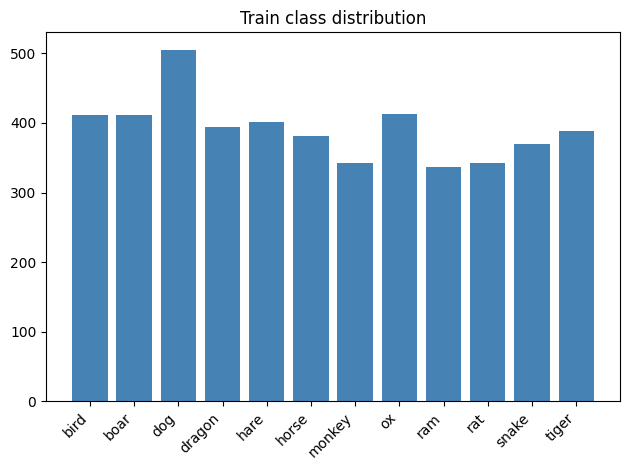

In [30]:
train_dataset = HandSealDataset(TRAIN_DIR_CROPPED, train_transforms, use_crop=False)
test_dataset  = HandSealDataset(TEST_DIR_CROPPED,  test_transforms,  use_crop=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0, pin_memory=False)

print(f"Train: {len(train_dataset)} images")
print(f"Test:  {len(test_dataset)} images")

# Class balance check
counts = Counter(label for _, label in train_dataset.samples)
plt.bar(SEAL_CLASSES, [counts[CLASS_TO_IDX[c]] for c in SEAL_CLASSES], color="steelblue")
plt.xticks(rotation=45, ha="right")
plt.title("Train class distribution")
plt.tight_layout()
plt.show()

## Model

frozen Backbone, trainable head

In [31]:
# Compute class weights
counts  = Counter(label for _, label in train_dataset.samples)
total   = sum(counts.values())
weights = torch.tensor(
    [total / (len(SEAL_CLASSES) * max(counts.get(CLASS_TO_IDX[c], 1), 1)) for c in SEAL_CLASSES],
    dtype=torch.float
).to(DEVICE)

class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0):
        super().__init__()
        self.weight = weight
        self.gamma  = gamma

    def forward(self, logits, targets):
        ce   = nn.functional.cross_entropy(logits, targets, weight=self.weight, reduction="none")
        pt   = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce
        return loss.mean()
    

criterion = FocalLoss(weight=weights, gamma=2.0)

In [32]:
def build_model(num_classes: int = 12) -> nn.Module:
    model = models.mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)

    # Freeze all backbone layers
    for p in model.features.parameters():
        p.requires_grad = False

    # Replace classifier head
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.8),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(p=0.5),
        nn.Linear(256, num_classes)
    )
    return model

model = build_model(num_classes=12).to(DEVICE)

# Count trainable params
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable:,} / {total:,} params")

Trainable: 331,020 / 2,554,892 params


In [33]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(imgs)
        correct += (logits.argmax(1) == labels).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)

@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits = model(imgs)
        total_loss += criterion(logits, labels).item() * len(imgs)
        correct += (logits.argmax(1) == labels).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)

## Phase 1

Train head only

In [34]:
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()), lr=LR
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS_PHASE_1
)

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

print("Phase 1: Training head only")
for epoch in range(EPOCHS_PHASE_1):
    model.train()
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer.step()

    scheduler.step()   # back to per epoch, not per batch

    tr_loss, tr_acc = eval_epoch(model, train_loader, criterion)
    va_loss, va_acc = eval_epoch(model, test_loader,  criterion)

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss)
    history["val_acc"].append(va_acc)

    print(f"Epoch {epoch+1:02d} | "
          f"train loss {tr_loss:.3f} acc {tr_acc:.3f} | "
          f"val loss {va_loss:.3f} acc {va_acc:.3f}")

Phase 1: Training head only


E0000 00:00:1777968728.435706   62880 portable_clearcut_uploader.cc:90] Failed to send to clearcut: FAILED_PRECONDITION: Not valid for uploading until: 2026-05-05T10:24:08.423504+02:00
=== Source Location Trace: ===
wireless/android/play/playlog/cplusplus/portable_clearcut_uploader.cc:180


Epoch 01 | train loss 1.728 acc 0.501 | val loss 1.836 acc 0.394


E0000 00:00:1777968773.651267   64820 portable_clearcut_uploader.cc:90] Failed to send to clearcut: FAILED_PRECONDITION: Not valid for uploading until: 2026-05-05T10:25:53.641358+02:00
=== Source Location Trace: ===
wireless/android/play/playlog/cplusplus/portable_clearcut_uploader.cc:180


Epoch 02 | train loss 1.229 acc 0.596 | val loss 1.455 acc 0.468


...

Epoch 13 | train loss 0.642 acc 0.741 | val loss 0.860 acc 0.620


E0000 00:00:1777969148.467020   62880 portable_clearcut_uploader.cc:90] Failed to send to clearcut: FAILED_PRECONDITION: Not valid for uploading until: 2026-05-05T10:24:08.423504+02:00
=== Source Location Trace: ===
wireless/android/play/playlog/cplusplus/portable_clearcut_uploader.cc:180


Epoch 14 | train loss 0.640 acc 0.739 | val loss 0.862 acc 0.621


E0000 00:00:1777969193.675866   64820 portable_clearcut_uploader.cc:90] Failed to send to clearcut: FAILED_PRECONDITION: Not valid for uploading until: 2026-05-05T10:25:53.641358+02:00
=== Source Location Trace: ===
wireless/android/play/playlog/cplusplus/portable_clearcut_uploader.cc:180


Epoch 15 | train loss 0.636 acc 0.739 | val loss 0.840 acc 0.620


## Phase 2: Train frozen backbone

In [35]:
# Unfreeze last 10 backbone blocks
for layer in list(model.features.children())[-10:]:
    for p in layer.parameters():
        p.requires_grad = True

optimizer = torch.optim.AdamW([
    {"params": model.features.parameters(), "lr": LR_BACKBONE},
    {"params": model.classifier.parameters(), "lr": LR}
])
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=[LR_BACKBONE, LR],
    steps_per_epoch=len(train_loader),
    epochs=EPOCHS_PHASE_2,
    pct_start=0.3
)

best_val_acc     = 0
patience_counter = 0

print("Phase 2: Fine-tuning backbone")
for epoch in range(EPOCHS_PHASE_2):
    model.train()
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer.step()
        scheduler.step()

    tr_loss, tr_acc = eval_epoch(model, train_loader, criterion)
    va_loss, va_acc = eval_epoch(model, test_loader,  criterion)

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss)
    history["val_acc"].append(va_acc)

    improved = va_acc > best_val_acc + MIN_DELTA
    if improved:
        best_val_acc     = va_acc
        patience_counter = 0
        torch.save(model.state_dict(), "mobilenetv2_best.pth")
    else:
        patience_counter += 1

    print(f"Epoch {epoch+11:02d} | "
          f"train loss {tr_loss:.3f} acc {tr_acc:.3f} | "
          f"val loss {va_loss:.3f} acc {va_acc:.3f}"
          + (" ← best" if improved else f" (patience {patience_counter}/{PATIENCE})"))

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+11}")
        break

print(f"\nBest val accuracy: {best_val_acc:.3f}")

Phase 2: Fine-tuning backbone


E0000 00:00:1777969208.471176   62880 portable_clearcut_uploader.cc:90] Failed to send to clearcut: FAILED_PRECONDITION: Not valid for uploading until: 2026-05-05T10:24:08.423504+02:00
=== Source Location Trace: ===
wireless/android/play/playlog/cplusplus/portable_clearcut_uploader.cc:180


Epoch 11 | train loss 0.595 acc 0.742 | val loss 0.806 acc 0.634 ← best


E0000 00:00:1777969253.678578   64820 portable_clearcut_uploader.cc:90] Failed to send to clearcut: FAILED_PRECONDITION: Not valid for uploading until: 2026-05-05T10:25:53.641358+02:00
=== Source Location Trace: ===
wireless/android/play/playlog/cplusplus/portable_clearcut_uploader.cc:180
E0000 00:00:1777969268.471760   62880 portable_clearcut_uploader.cc:90] Failed to send to clearcut: FAILED_PRECONDITION: Not valid for uploading until: 2026-05-05T10:24:08.423504+02:00
=== Source Location Trace: ===
wireless/android/play/playlog/cplusplus/portable_clearcut_uploader.cc:180


Epoch 12 | train loss 0.546 acc 0.769 | val loss 0.715 acc 0.671 ← best
Epoch 13 | train loss 0.429 acc 0.807 | val loss 0.580 acc 0.738 ← best


...

Epoch 15 | train loss 0.248 acc 0.876 | val loss 0.300 acc 0.851 ← best


E0000 00:00:1777969388.477891   62880 portable_clearcut_uploader.cc:90] Failed to send to clearcut: FAILED_PRECONDITION: Not valid for uploading until: 2026-05-05T10:24:08.423504+02:00
=== Source Location Trace: ===
wireless/android/play/playlog/cplusplus/portable_clearcut_uploader.cc:180


Epoch 16 | train loss 0.174 acc 0.898 | val loss 0.191 acc 0.900 ← best


E0000 00:00:1777969433.687654   64820 portable_clearcut_uploader.cc:90] Failed to send to clearcut: FAILED_PRECONDITION: Not valid for uploading until: 2026-05-05T10:25:53.641358+02:00
=== Source Location Trace: ===
wireless/android/play/playlog/cplusplus/portable_clearcut_uploader.cc:180


Epoch 17 | train loss 0.127 acc 0.928 | val loss 0.122 acc 0.933 ← best
Epoch 18 | train loss 0.102 acc 0.941 | val loss 0.079 acc 0.948 ← best
Epoch 19 | train loss 0.079 acc 0.949 | val loss 0.065 acc 0.954 ← best
Epoch 20 | train loss 0.060 acc 0.964 | val loss 0.056 acc 0.964 ← best
Epoch 21 | train loss 0.057 acc 0.967 | val loss 0.039 acc 0.976 ← best
Epoch 22 | train loss 0.044 acc 0.974 | val loss 0.036 acc 0.974 (patience 1/8)
Epoch 23 | train loss 0.042 acc 0.973 | val loss 0.032 acc 0.976 (patience 2/8)
Epoch 24 | train loss 0.034 acc 0.980 | val loss 0.029 acc 0.984 ← best
Epoch 25 | train loss 0.030 acc 0.982 | val loss 0.027 acc 0.985 (patience 1/8)
Epoch 26 | train loss 0.029 acc 0.980 | val loss 0.025 acc 0.987 (patience 2/8)
Epoch 27 | train loss 0.027 acc 0.987 | val loss 0.026 acc 0.984 (patience 3/8)
Epoch 28 | train loss 0.030 acc 0.983 | val loss 0.027 acc 0.984 (patience 4/8)
Epoch 29 | train loss 0.025 acc 0.984 | val loss 0.027 acc 0.982 (patience 5/8)
Epoch 30

## Analysis

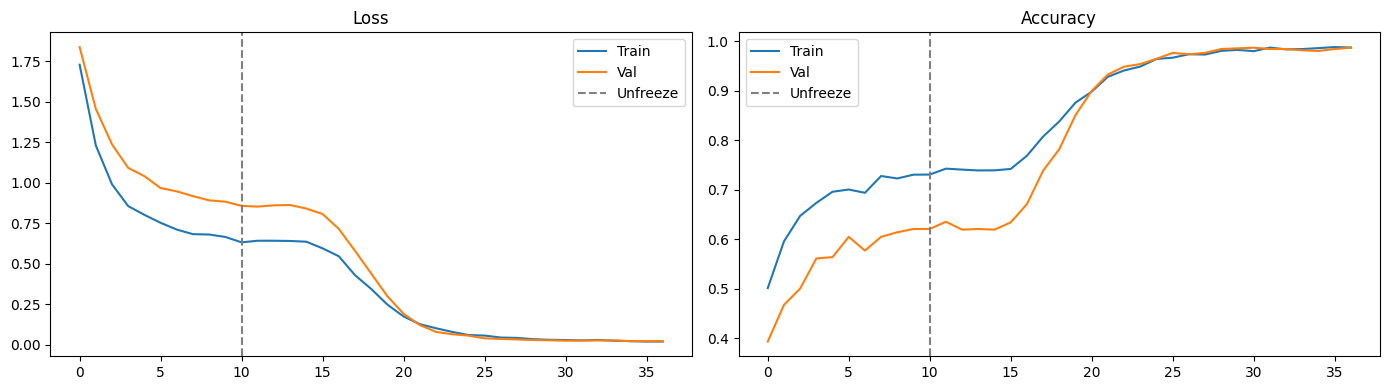

In [36]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(history["train_loss"], label="Train")
ax1.plot(history["val_loss"],   label="Val")
ax1.axvline(10, color="gray", linestyle="--", label="Unfreeze")
ax1.set_title("Loss"); ax1.legend()

ax2.plot(history["train_acc"], label="Train")
ax2.plot(history["val_acc"],   label="Val")
ax2.axvline(10, color="gray", linestyle="--", label="Unfreeze")
ax2.set_title("Accuracy"); ax2.legend()

plt.tight_layout()
plt.show()

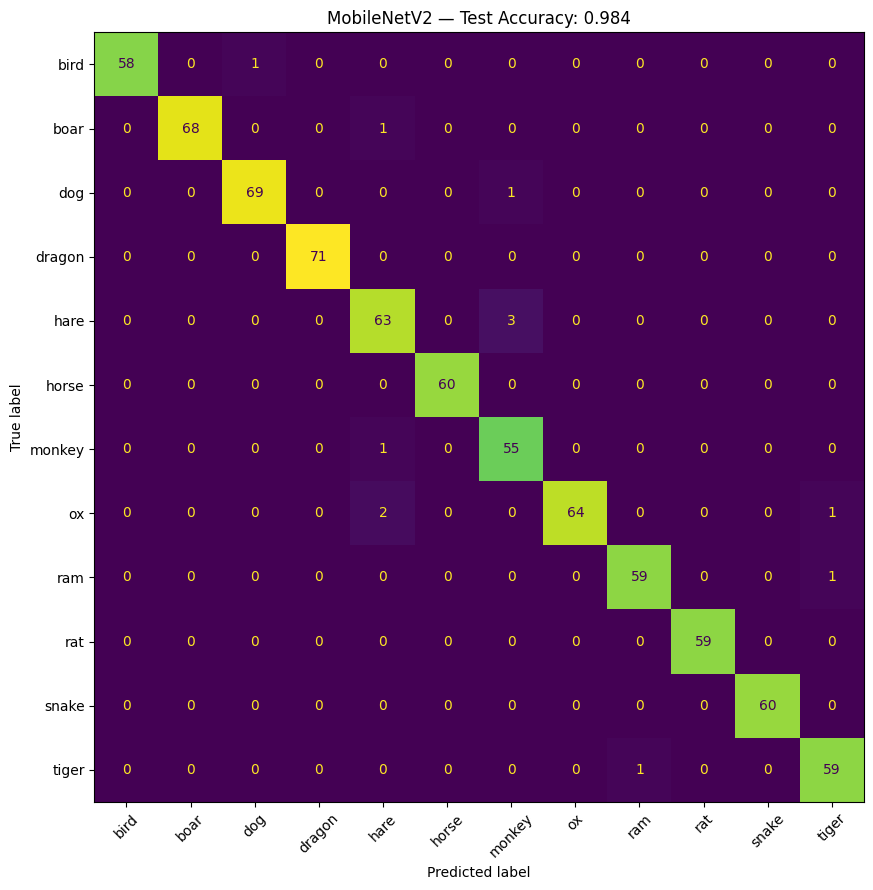

In [37]:
model.load_state_dict(torch.load("mobilenetv2_best.pth", map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        preds = model(imgs.to(DEVICE)).argmax(1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=SEAL_CLASSES)

fig, ax = plt.subplots(figsize=(11, 9))
disp.plot(ax=ax, colorbar=False, xticks_rotation=45)
plt.title(f"MobileNetV2 — Test Accuracy: {accuracy_score(all_labels, all_preds):.3f}")
plt.tight_layout()
plt.show()

In [38]:
model.eval()
top3_correct = 0
with torch.no_grad():
    for imgs, labels in test_loader:
        logits = model(imgs.to(DEVICE))
        top3 = logits.topk(3, dim=1).indices.cpu()
        for pred_top3, label in zip(top3, labels):
            if label in pred_top3:
                top3_correct += 1

print(f"Top-1 accuracy: {accuracy_score(all_labels, all_preds):.3f}")
print(f"Top-3 accuracy: {top3_correct / len(test_dataset):.3f}")

Top-1 accuracy: 0.984
Top-3 accuracy: 0.999
